# Stage 4 — Feature Engineering

**Project:** Medical Device Safety Event Severity Prediction  
**Target:** `is_class_i` — binary (1 = Class I severity, 0 = Class II/III)  
**Data source:** `data/processed/merged.parquet`  
**Output:** `data/features/{train,validation,test,holdout_2018}.parquet`

---

This notebook demonstrates the feature-engineering pipeline end-to-end using the **real project data**.  
It serves as exploratory documentation. The production pipeline is `src/features/build_features.py`.

### Sections
1. Load processed data  
2. Target construction  
3. Feature tiers overview  
4. Load generated feature outputs  
5. Feature inventory  
6. Missing-value analysis  
7. Historical feature distributions  
8. Leakage checks  
9. Temporal split visualization  
10. Target distribution by split  
11. Feature-level visualizations  
12. Feature matrix summary  

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.edgecolor': '#dee2e6',
    'axes.grid': True,
    'grid.color': '#e9ecef',
    'grid.linewidth': 0.8,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
})

ROOT = Path('..').resolve()
PROCESSED = ROOT / 'data' / 'processed'
FEATURES = ROOT / 'data' / 'features'

print(f'Project root: {ROOT}')
print(f'Processed data: {PROCESSED}')
print(f'Features data:  {FEATURES}')

Project root: /Users/kaushalpokarne/Downloads/medical-device-risk
Processed data: /Users/kaushalpokarne/Downloads/medical-device-risk/data/processed
Features data:  /Users/kaushalpokarne/Downloads/medical-device-risk/data/features


---
## 1. Load Processed Data

In [2]:
merged = pd.read_parquet(PROCESSED / 'merged.parquet')
print(f'merged.parquet: {merged.shape[0]:,} rows x {merged.shape[1]} columns')
print(f'Date range:     {merged["event_date"].min()} to {merged["event_date"].max()}')
merged.head(3)

merged.parquet: 124,969 rows x 56 columns
Date range:     1991-08-07 00:00:00 to 2019-06-18 00:00:00


,id,action,action_classification,action_level,action_summary,authorities_link,country,create_date,data_notes,date,...,device_updated_at,mfr_address,mfr_comment,mfr_name,mfr_parent_company,mfr_representative,mfr_slug,mfr_source,mfr_created_at,mfr_updated_at
0,1,<NA>,<NA>,<NA>,Recall,https://www.titck.gov.tr/,TUR,NaT,<NA>,2016-04-04,...,2022-08-04 08:28:00+00:00,<NA>,“We are in constant communication with regulat...,Abbot Laboratories,Abbott Laboratories,<NA>,turkey-drugs-and-medical-devices-agency-titck-...,Turkey Drugs and Medical Devices Agency (Titck),2022-08-04 08:28:00+00:00,2022-08-04 08:28:00+00:00
1,2,<NA>,<NA>,<NA>,Recall,https://www.titck.gov.tr/,TUR,NaT,<NA>,2016-09-20,...,2022-08-04 08:28:00+00:00,<NA>,<NA>,Abbott Medical Optics (AMO) Inc.,Johnson & Johnson,<NA>,turkey-drugs-and-medical-devices-agency-titck-...,Turkey Drugs and Medical Devices Agency (Titck),2022-08-04 08:28:00+00:00,2022-08-04 08:28:00+00:00
2,3,<NA>,<NA>,<NA>,Recall,https://www.titck.gov.tr/,TUR,NaT,<NA>,2016-05-09,...,2022-08-04 08:28:00+00:00,<NA>,<NA>,Alcon Laboratories Inc.,Novartis Ag,<NA>,turkey-drugs-and-medical-devices-agency-titck-...,Turkey Drugs and Medical Devices Agency (Titck),2022-08-04 08:28:00+00:00,2022-08-04 08:28:00+00:00


---
## 2. Target Construction

**Positive (1):** `action_classification == 'Class I'` — most severe  
**Negative (0):** `action_classification in {'Class II', 'Class III'}`  
**Excluded:** null, 'Unclassified Correction', 'Voluntary recall'

In [3]:
EXCLUDE_VALUES = {'Unclassified Correction', 'Voluntary recall'}
labeled = merged[
    merged['action_classification'].notna() &
    ~merged['action_classification'].isin(EXCLUDE_VALUES)
].copy()
labeled['is_class_i'] = (labeled['action_classification'] == 'Class I').astype(int)

print(f'Total events:       {len(merged):>7,}')
print(f'Labeled events:     {len(labeled):>7,}  ({len(labeled)/len(merged)*100:.1f}% of total)')
print(f'Unlabeled/excluded: {len(merged)-len(labeled):>7,}')
print()
dist = labeled['action_classification'].value_counts()
for cls, cnt in dist.items():
    print(f'  {cls:<45} {cnt:>6,}  ({cnt/len(labeled)*100:.1f}%)')
print(f'\nPositive (Class I):  {labeled["is_class_i"].sum():,}  ({labeled["is_class_i"].mean()*100:.1f}%)')
print(f'Negative (II/III):   {(1-labeled["is_class_i"]).sum():,}  ({(1-labeled["is_class_i"].mean())*100:.1f}%)')

Total events:       124,969
Labeled events:      52,946  (42.4% of total)
Unlabeled/excluded:  72,023

  Class II                                      41,834  (79.0%)
  Class III                                      7,090  (13.4%)
  Class I                                        4,022  (7.6%)

Positive (Class I):  4,022  (7.6%)
Negative (II/III):   48,924  (92.4%)


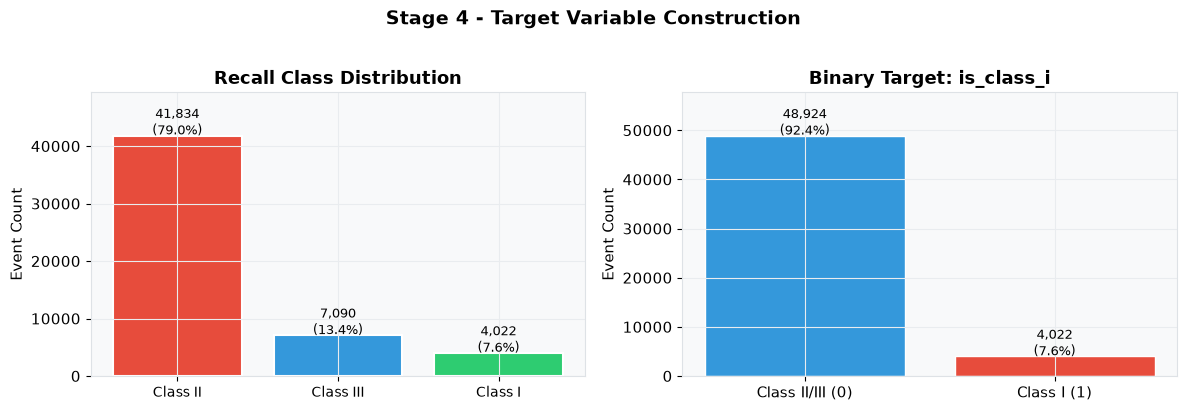

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cls_counts = labeled['action_classification'].value_counts()
colors_cls = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].bar(range(len(cls_counts)), cls_counts.values, color=colors_cls[:len(cls_counts)], edgecolor='white', linewidth=1.5)
axes[0].set_xticks(range(len(cls_counts)))
axes[0].set_xticklabels(cls_counts.index, rotation=0, ha='center', fontsize=10)
axes[0].set_title('Recall Class Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Event Count')
for i, v in enumerate(cls_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(labeled)*100:.1f}%)', ha='center', fontsize=9)
axes[0].set_ylim(0, max(cls_counts.values) * 1.18)

binary_counts = labeled['is_class_i'].value_counts().sort_index()
axes[1].bar(['Class II/III (0)', 'Class I (1)'], binary_counts.values, color=['#3498db', '#e74c3c'], edgecolor='white')
axes[1].set_title('Binary Target: is_class_i', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Event Count')
for i, v in enumerate(binary_counts.values):
    axes[1].text(i, v + 200, f'{v:,}\n({v/len(labeled)*100:.1f}%)', ha='center', fontsize=9)
axes[1].set_ylim(0, max(binary_counts.values) * 1.18)

plt.suptitle('Stage 4 - Target Variable Construction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Feature Tiers Overview

| Tier | Features | Leakage Status | Encoding |
|------|---------|---------------|----------|
| **Tier 1 - Safe Static** | Device classification, risk_class, implanted, country, description/name length; Manufacturer parent_company, source | Pre-event static — safe | One-hot / Frequency |
| **Tier 2a - Event Context** | `type` | Known at initiation | One-hot |
| **Tier 2b - Temporal Historical** | Cumulative counts per device/manufacturer/category | Strict `event_date < T`, same-day excluded | Numeric |
| **Tier 3 - Excluded** | `reason` text | Borderline leakage — excluded | — |
| **Prohibited** | action, action_summary, determined_cause, status, date_terminated, action_classification | Post-event — BLOCKED | — |

---
## 4. Load Generated Feature Outputs

In [5]:
train   = pd.read_parquet(FEATURES / 'train.parquet')
val     = pd.read_parquet(FEATURES / 'validation.parquet')
test    = pd.read_parquet(FEATURES / 'test.parquet')
holdout = pd.read_parquet(FEATURES / 'holdout_2018.parquet')

with open(FEATURES / 'feature_metadata.json') as f:
    meta = json.load(f)

splits = {'Train': train, 'Validation': val, 'Test': test, 'Holdout 2018': holdout}

print(f'Pipeline version: {meta["pipeline_version"]}')
print(f'Total features:   {meta["n_features"]}')
print(f'Metadata columns: {meta["metadata_columns"]}')
print()
print(f'{"Split":<16} {"Rows":>7}  {"Cols":>5}  {"Pos":>6}  {"Pos%":>7}  {"Date Range"}')
print('-' * 75)
for name, df in splits.items():
    pos = df['is_class_i'].sum()
    d0 = df['event_date'].min().strftime('%Y-%m-%d')
    d1 = df['event_date'].max().strftime('%Y-%m-%d')
    print(f'{name:<16} {len(df):>7,}  {len(df.columns):>5}  {pos:>6,}  {pos/len(df)*100:>6.2f}%  {d0} to {d1}')
print(f'{"TOTAL":<16} {sum(len(df) for df in splits.values()):>7,}')

Pipeline version: 4.0.0
Total features:   62
Metadata columns: ['device_id', 'event_date', 'event_date_available', 'id', 'manufacturer_id']

Split               Rows   Cols     Pos     Pos%  Date Range
---------------------------------------------------------------------------
Train             38,247     68   3,191    8.34%  1991-08-07 to 2014-12-31
Validation         4,273     68     250    5.85%  2015-01-01 to 2015-12-31
Test               8,918     68     492    5.52%  2016-01-04 to 2017-12-29
Holdout 2018       1,361     68      74    5.44%  2018-01-02 to 2018-07-09
TOTAL             52,799


---
## 5. Feature Inventory

In [6]:
feature_cols = meta['feature_columns']
tier2b = [c for c in feature_cols if c.startswith('hist_')]
tier2a = [c for c in feature_cols if c.startswith('type_')]
tier1  = [c for c in feature_cols if not c.startswith('hist_') and not c.startswith('type_')]

print(f'Total features: {len(feature_cols)}')
print(f'  Tier 1 (static):            {len(tier1)}')
print(f'  Tier 2a (event type):       {len(tier2a)}')
print(f'  Tier 2b (temporal hist):    {len(tier2b)}')
print()
print('=== Tier 2b: Temporal Historical ===')
for fc in tier2b:
    print(f'  {fc}')
print()
print('=== Tier 1 Sample (first 10) ===')
for fc in tier1[:10]:
    print(f'  {fc}')
print(f'  ... (+{len(tier1)-10} more)')

Total features: 62
  Tier 1 (static):            48
  Tier 2a (event type):       2
  Tier 2b (temporal hist):    12

=== Tier 2b: Temporal Historical ===
  hist_category_class_i_count
  hist_category_event_count
  hist_category_severity_rate
  hist_category_severity_rate_available
  hist_device_class_i_count
  hist_device_event_count
  hist_device_recall_count
  hist_mfr_class_i_count
  hist_mfr_event_count
  hist_mfr_recall_count
  hist_mfr_severity_rate
  hist_mfr_severity_rate_available

=== Tier 1 Sample (first 10) ===
  country_AUS
  country_CAN
  country_USA
  country___UNKNOWN__
  device_classification_Anesthesiology Devices
  device_classification_Cardiovascular Devices
  device_classification_Clinical Chemistry and Clinical Toxicology Devices
  device_classification_Dental Devices
  device_classification_Ear, Nose, and Throat Devices
  device_classification_Gastroenterology-Urology Devices
  ... (+38 more)


---
## 6. Missing-Value Analysis

In [7]:
print('Missing values in train feature columns:')
null_counts = train[feature_cols].isnull().sum()
has_null = null_counts[null_counts > 0]
if len(has_null) == 0:
    print('  No NaN values in any feature column - all missingness handled explicitly.')
else:
    print(has_null)
print()
print('Missing indicator columns (fraction originally missing in train):')
miss_cols = [c for c in feature_cols if c.endswith('_missing')]
for col in miss_cols:
    frac = train[col].mean() * 100
    print(f'  {col:<45} {frac:.1f}%')

Missing values in train feature columns:
  No NaN values in any feature column - all missingness handled explicitly.

Missing indicator columns (fraction originally missing in train):
  device_classification_missing                 32.4%
  device_implanted_missing                      33.5%
  device_risk_class_missing                     33.5%


---
## 7. Historical Feature Distributions

In [8]:
hist_count_cols = [c for c in feature_cols if c.startswith('hist_') and 'rate' not in c and 'available' not in c]
hist_rate_cols  = [c for c in feature_cols if c.startswith('hist_') and 'rate' in c and 'available' not in c]

print('Historical COUNT features — train statistics:')
df_stats = train[hist_count_cols].describe().T[['mean', 'std', '50%', 'max']]
df_stats.columns = ['Mean', 'Std', 'Median', 'Max']
print(df_stats.round(2).to_string())
print()
print('Historical RATE features — train statistics:')
df_rate = train[hist_rate_cols].describe().T[['mean', 'std', '50%', 'max']]
df_rate.columns = ['Mean', 'Std', 'Median', 'Max']
print(df_rate.round(4).to_string())

Historical COUNT features — train statistics:


                               Mean      Std  Median     Max
hist_category_class_i_count   62.04   125.05     9.0   689.0
hist_category_event_count    904.07  1077.71   442.0  4340.0
hist_device_class_i_count      0.00     0.03     0.0     2.0
hist_device_event_count        0.01     0.14     0.0     6.0
hist_device_recall_count       0.01     0.14     0.0     6.0
hist_mfr_class_i_count         2.54    16.80     0.0   233.0
hist_mfr_event_count          45.00    89.19     8.0   763.0
hist_mfr_recall_count         45.00    89.19     8.0   763.0

Historical RATE features — train statistics:
                               Mean     Std  Median  Max
hist_category_severity_rate  0.0407  0.0588  0.0129  1.0
hist_mfr_severity_rate       0.0436  0.1446  0.0000  1.0


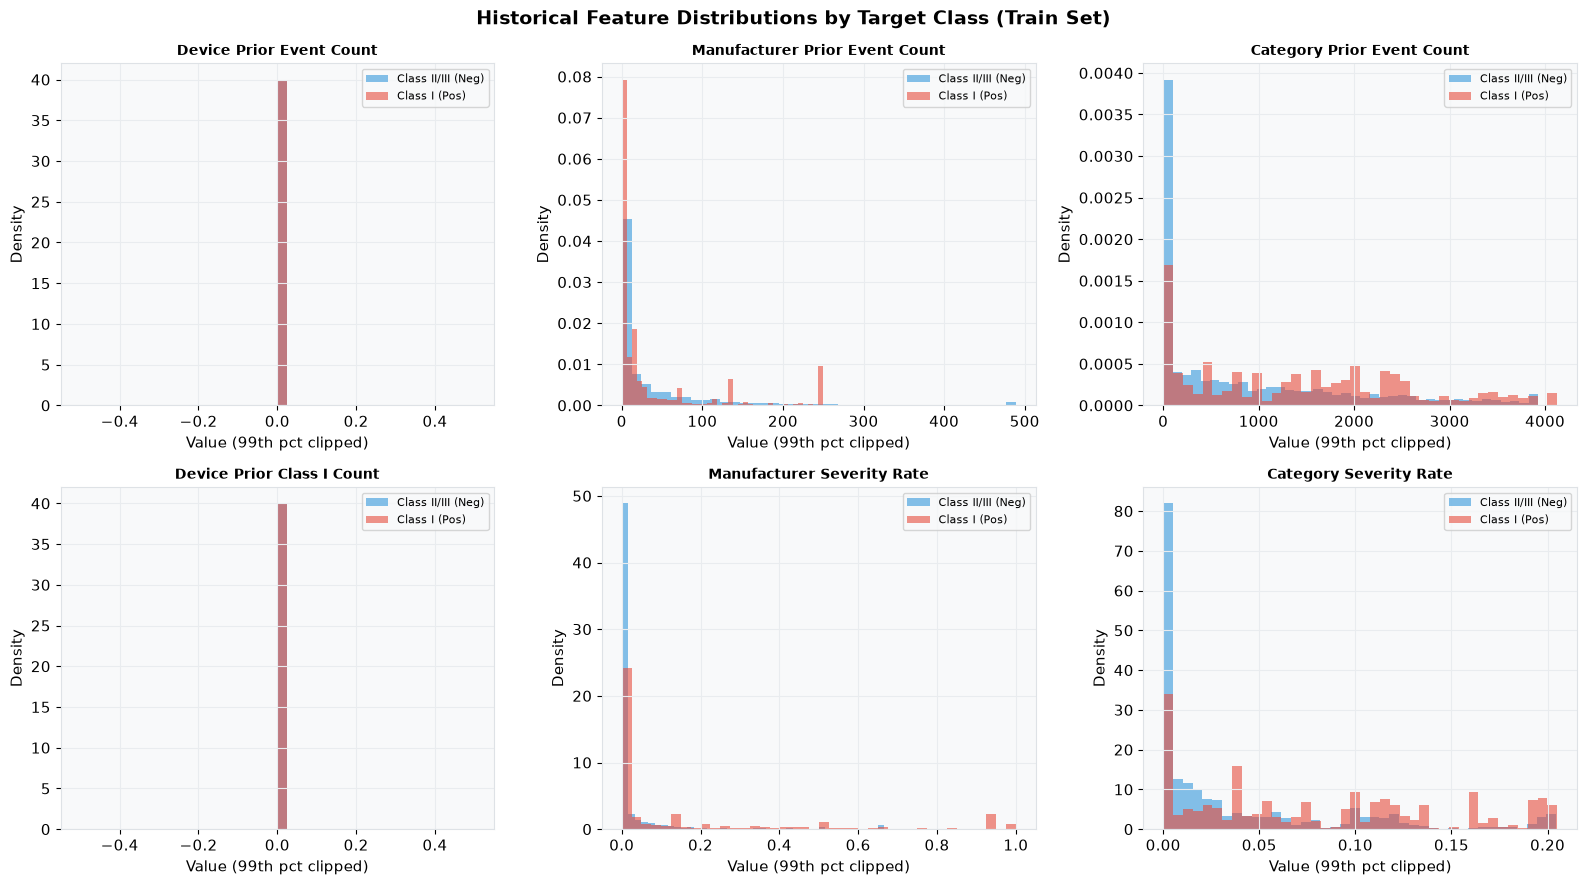

In [9]:
plot_features = [
    ('hist_device_event_count', 'Device Prior Event Count'),
    ('hist_mfr_event_count', 'Manufacturer Prior Event Count'),
    ('hist_category_event_count', 'Category Prior Event Count'),
    ('hist_device_class_i_count', 'Device Prior Class I Count'),
    ('hist_mfr_severity_rate', 'Manufacturer Severity Rate'),
    ('hist_category_severity_rate', 'Category Severity Rate'),
]
colors_cls = {0: '#3498db', 1: '#e74c3c'}
labels_cls = {0: 'Class II/III (Neg)', 1: 'Class I (Pos)'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, (col, title) in zip(axes, plot_features):
    for cls in [0, 1]:
        data = train.loc[train['is_class_i'] == cls, col]
        clip_val = data.quantile(0.99)
        ax.hist(data.clip(upper=clip_val), bins=40, alpha=0.6, color=colors_cls[cls],
                label=labels_cls[cls], density=True, edgecolor='none')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value (99th pct clipped)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.suptitle('Historical Feature Distributions by Target Class (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Leakage Checks

In [10]:
prohibited = set(meta['prohibited_features'])
features   = set(meta['feature_columns'])

print('=== Leakage Validation ===')
print()

ok1 = meta['target'] not in features
print(f'1.  Target not in features:                 {"PASS" if ok1 else "FAIL"}')

overlap = prohibited & features
ok2 = len(overlap) == 0
print(f'2.  Prohibited intersection empty:          {"PASS" if ok2 else "FAIL"}')
if not ok2: print(f'    Leaking: {overlap}')

train_df = splits['Train']
val_df   = splits['Validation']
test_df  = splits['Test']
hold_df  = splits['Holdout 2018']

ok3 = train_df['event_date'].max() <= pd.Timestamp('2014-12-31')
print(f'3.  Train max date <= 2014-12-31:            {"PASS" if ok3 else "FAIL"}  ({train_df["event_date"].max().date()})')

ok4 = val_df['event_date'].min() >= pd.Timestamp('2015-01-01') and val_df['event_date'].max() <= pd.Timestamp('2015-12-31')
print(f'4.  Val date range 2015:                    {"PASS" if ok4 else "FAIL"}  ({val_df["event_date"].min().date()} to {val_df["event_date"].max().date()})')

ok5 = test_df['event_date'].min() >= pd.Timestamp('2016-01-01') and test_df['event_date'].max() <= pd.Timestamp('2017-12-31')
print(f'5.  Test date range 2016-2017:              {"PASS" if ok5 else "FAIL"} ({test_df["event_date"].min().date()} to {test_df["event_date"].max().date()})')

ok6 = hold_df['event_date'].min() >= pd.Timestamp('2018-01-01')
print(f'6.  Holdout min date >= 2018-01-01:         {"PASS" if ok6 else "FAIL"}  ({hold_df["event_date"].min().date()})')

train_ids = set(train_df['id']); val_ids = set(val_df['id']); test_ids = set(test_df['id']); hold_ids = set(hold_df['id'])
print(f'7.  Train/Val overlap == 0:                 {"PASS" if len(train_ids & val_ids) == 0 else "FAIL"}')
print(f'8.  Train/Test overlap == 0:                {"PASS" if len(train_ids & test_ids) == 0 else "FAIL"}')
print(f'9.  Val/Test overlap == 0:                  {"PASS" if len(val_ids & test_ids) == 0 else "FAIL"}')
print(f'10. Train/Holdout overlap == 0:             {"PASS" if len(train_ids & hold_ids) == 0 else "FAIL"}')

print()
dated_all = pd.read_parquet(PROCESSED / 'merged.parquet')
dated_all = dated_all[dated_all['event_date'].notna()]
first_evt = dated_all.groupby('device_id')['event_date'].min().reset_index()
first_evt.columns = ['device_id', 'first_date']
check = train_df.merge(first_evt, on='device_id', how='inner')
first_in_train = check[check['event_date'] == check['first_date']]
ok11 = (first_in_train['hist_device_event_count'] == 0).all()
print(f'11. Same-day exclusion (first events have 0 device history): {"PASS" if ok11 else "FAIL"}')
print(f'    Checked {len(first_in_train):,} first-ever device events in train set')


=== Leakage Validation ===

1.  Target not in features:                 PASS
2.  Prohibited intersection empty:          PASS
3.  Train max date <= 2014-12-31:            PASS  (2014-12-31)
4.  Val date range 2015:                    PASS  (2015-01-01 to 2015-12-31)
5.  Test date range 2016-2017:              PASS (2016-01-04 to 2017-12-29)
6.  Holdout min date >= 2018-01-01:         PASS  (2018-01-02)
7.  Train/Val overlap == 0:                 PASS
8.  Train/Test overlap == 0:                PASS
9.  Val/Test overlap == 0:                  PASS
10. Train/Holdout overlap == 0:             PASS

11. Same-day exclusion (first events have 0 device history): PASS
    Checked 37,995 first-ever device events in train set


---
## 9. Temporal Split Visualization

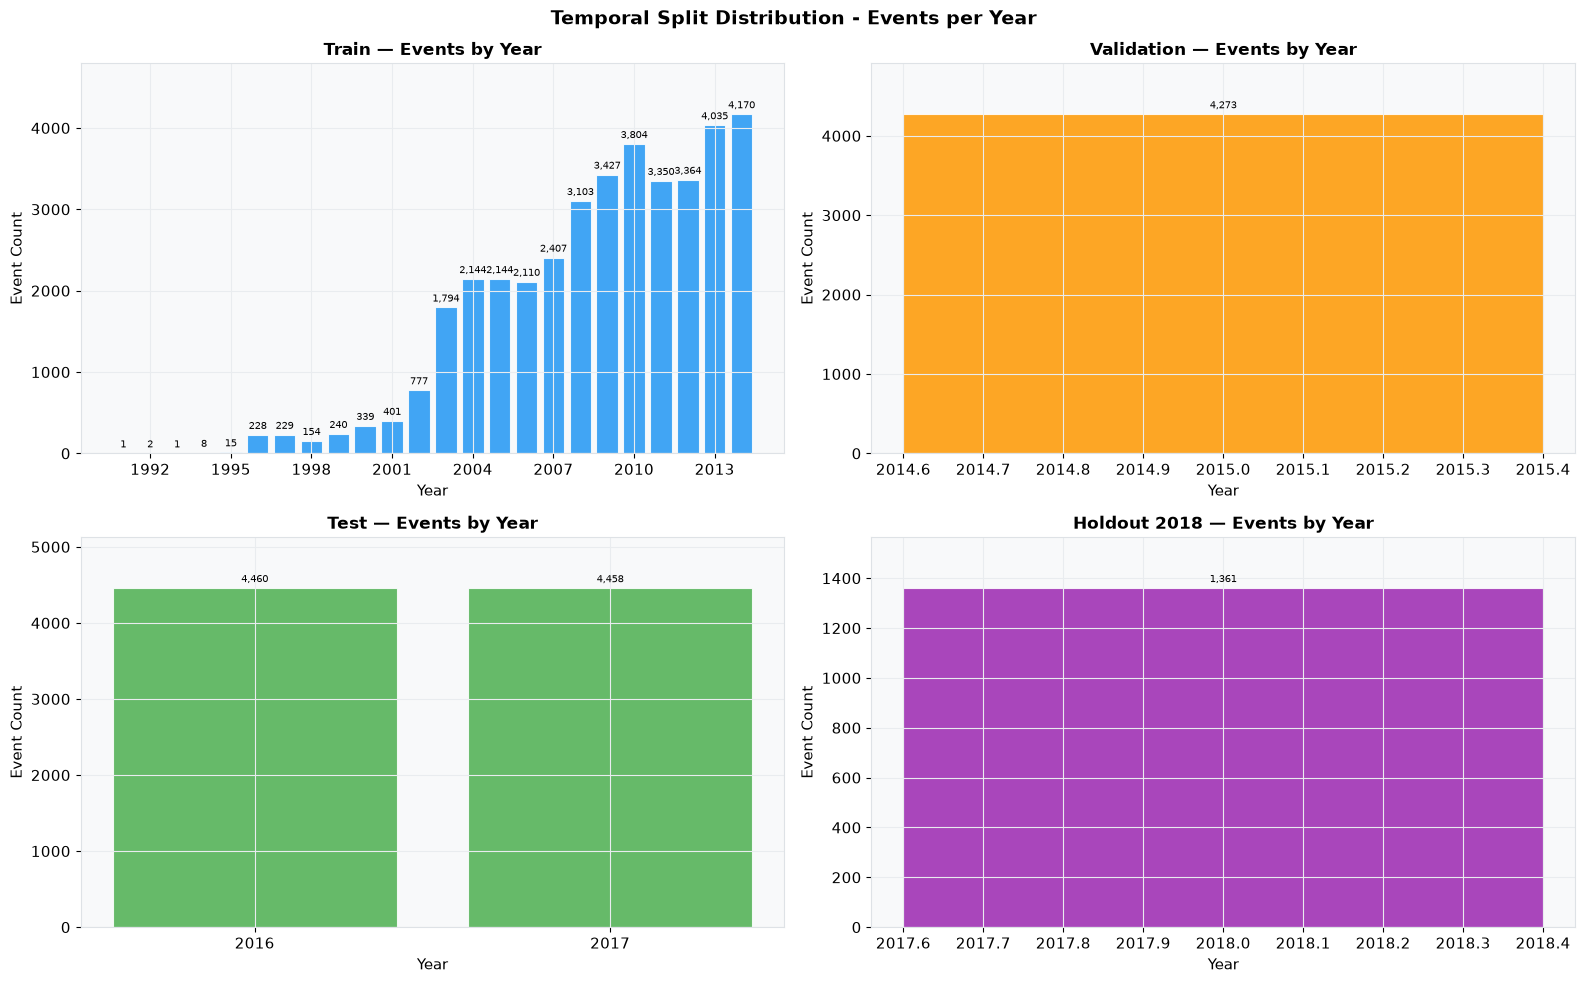

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
colors_split = {'Train': '#2196F3', 'Validation': '#FF9800', 'Test': '#4CAF50', 'Holdout 2018': '#9C27B0'}

for ax, (name, df) in zip(axes, splits.items()):
    years = df['event_date'].dt.year.value_counts().sort_index()
    ax.bar(years.index, years.values, color=colors_split[name], alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{name} — Events by Year', fontweight='bold', fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Event Count')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for x, y in zip(years.index, years.values):
        ax.text(x, y + max(years.values)*0.01, f'{y:,}', ha='center', va='bottom', fontsize=7.5)
    ax.set_ylim(0, max(years.values) * 1.15)

plt.suptitle('Temporal Split Distribution - Events per Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Target Distribution by Split

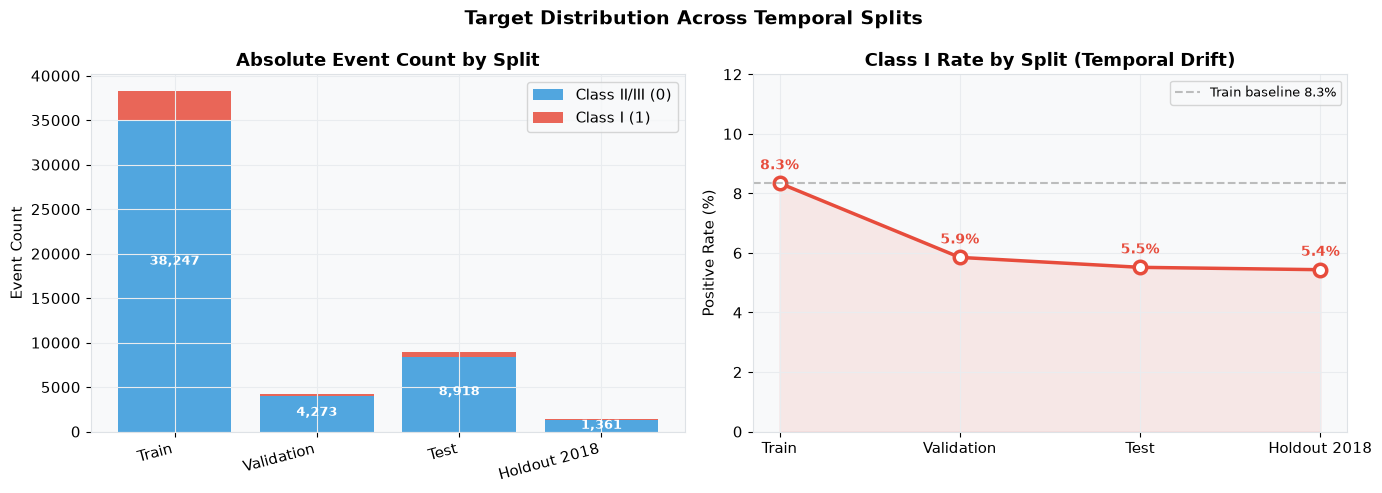

Note: Positive rate shifts from 8.3% (train) to ~5.4% (test/holdout). This temporal drift is expected.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
split_names = list(splits.keys())
pos_rate = [df['is_class_i'].mean()*100 for df in splits.values()]
positives = [df['is_class_i'].sum() for df in splits.values()]
negatives = [len(df) - p for df, p in zip(splits.values(), positives)]

x = range(len(split_names))
axes[0].bar(x, negatives, label='Class II/III (0)', color='#3498db', alpha=0.85)
axes[0].bar(x, positives, bottom=negatives, label='Class I (1)', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_names, rotation=15, ha='right')
axes[0].set_title('Absolute Event Count by Split', fontweight='bold')
axes[0].set_ylabel('Event Count')
axes[0].legend()
for xi, (neg, pos) in enumerate(zip(negatives, positives)):
    axes[0].text(xi, (neg + pos)/2, f'{neg+pos:,}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

axes[1].plot(split_names, pos_rate, 'o-', color='#e74c3c', linewidth=2.5, markersize=9, markerfacecolor='white', markeredgewidth=2.5)
axes[1].fill_between(split_names, pos_rate, alpha=0.1, color='#e74c3c')
axes[1].set_title('Class I Rate by Split (Temporal Drift)', fontweight='bold')
axes[1].set_ylabel('Positive Rate (%)')
axes[1].set_ylim(0, 12)
for xi, rate in enumerate(pos_rate):
    axes[1].annotate(f'{rate:.1f}%', (xi, rate), textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=10, fontweight='bold', color='#e74c3c')
axes[1].axhline(y=pos_rate[0], color='gray', linestyle='--', alpha=0.5, label=f'Train baseline {pos_rate[0]:.1f}%')
axes[1].legend(fontsize=9)

plt.suptitle('Target Distribution Across Temporal Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Note: Positive rate shifts from 8.3% (train) to ~5.4% (test/holdout). This temporal drift is expected.')

---
## 11. Feature-Level Visualizations

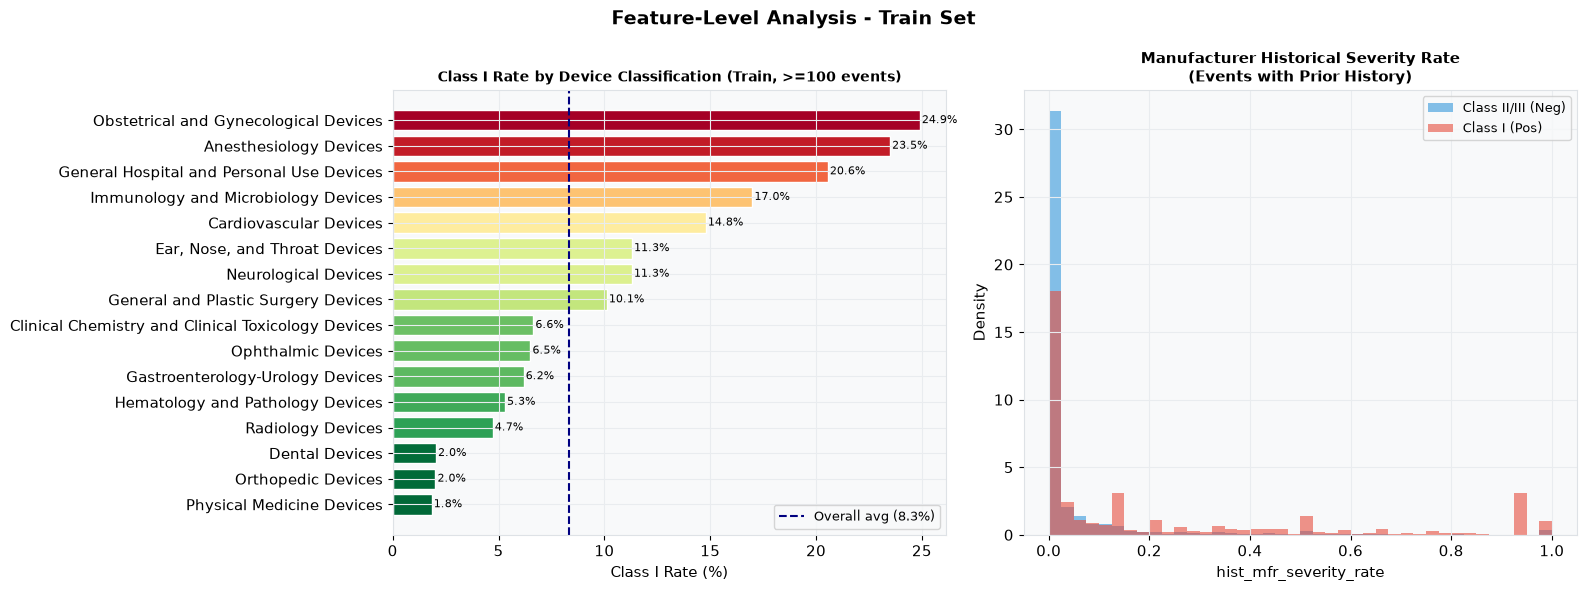

In [13]:
# Class I rate by device classification
dev_cls_cols = [c for c in train.columns if c.startswith('device_classification_')
                and c not in ('device_classification___MISSING__', 'device_classification___UNKNOWN__', 'device_classification_missing')]
cls_stats = []
for col in dev_cls_cols:
    cat = col.replace('device_classification_', '')
    subset = train[train[col] == 1]
    if len(subset) >= 100:
        cls_stats.append({'category': cat, 'count': len(subset), 'class_i_rate': subset['is_class_i'].mean()*100})

cls_df = pd.DataFrame(cls_stats).sort_values('class_i_rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

norm = cls_df['class_i_rate'].values
vmin, vmax = norm.min(), norm.max()
bar_colors = plt.cm.RdYlGn_r([(v - vmin)/(vmax - vmin + 1e-9) for v in norm])
bars = axes[0].barh(cls_df['category'], cls_df['class_i_rate'], color=bar_colors, edgecolor='white')
axes[0].axvline(x=train['is_class_i'].mean()*100, color='navy', linestyle='--', linewidth=1.5,
                label=f'Overall avg ({train["is_class_i"].mean()*100:.1f}%)')
axes[0].set_title('Class I Rate by Device Classification (Train, >=100 events)', fontweight='bold', fontsize=10)
axes[0].set_xlabel('Class I Rate (%)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, norm):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8)

# Manufacturer severity rate by class
has_hist = train['hist_mfr_severity_rate_available'] == 1
pos_h = train[has_hist & (train['is_class_i'] == 1)]['hist_mfr_severity_rate']
neg_h = train[has_hist & (train['is_class_i'] == 0)]['hist_mfr_severity_rate']
axes[1].hist(neg_h, bins=40, alpha=0.6, color='#3498db', label='Class II/III (Neg)', density=True)
axes[1].hist(pos_h, bins=40, alpha=0.6, color='#e74c3c', label='Class I (Pos)', density=True)
axes[1].set_title('Manufacturer Historical Severity Rate\n(Events with Prior History)', fontweight='bold', fontsize=11)
axes[1].set_xlabel('hist_mfr_severity_rate')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.suptitle('Feature-Level Analysis - Train Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print('=== Categorical Encoding Summary ===')
for col, enc in meta['encoding'].items():
    method = enc['method']
    n = enc['n_unique_train']
    if method == 'one_hot':
        n_cols = len(enc['categories'])
        print(f'{col:<35} one-hot      {n:>5} categories -> {n_cols} columns')
    else:
        print(f'{col:<35} frequency    {n:>5} categories -> 1 column')

=== Categorical Encoding Summary ===
device_classification               one-hot         17 categories -> 18 columns
device_risk_class                   one-hot          7 categories -> 8 columns
device_implanted                    one-hot          3 categories -> 4 columns
device_country                      one-hot          3 categories -> 4 columns
mfr_parent_company                  frequency     1075 categories -> 1 column
mfr_source                          one-hot          3 categories -> 4 columns
country                             one-hot          3 categories -> 4 columns
type                                one-hot          1 categories -> 2 columns


---
## 12. Feature Matrix Summary

In [15]:
metadata_cols = meta['metadata_columns']
train_df = splits['Train']
val_df   = splits['Validation']
test_df  = splits['Test']
hold_df  = splits['Holdout 2018']
X_cols = [c for c in train_df.columns if c not in metadata_cols and c != 'is_class_i']

print('=' * 60)
print('STAGE 4 FEATURE MATRIX - FINAL SUMMARY')
print('=' * 60)
print(f'Target:          is_class_i (1=Class I, 0=Class II/III)')
print(f'Total features:  {len(X_cols)}')
print(f'Metadata cols:   {len(metadata_cols)} (id, device_id, manufacturer_id, event_date, event_date_available)')
print()
print('Feature matrix shapes (X = features only):')
print(f'  X_train:   ({len(train_df):>6,}, {len(X_cols)})')
print(f'  X_val:     ({len(val_df):>6,}, {len(X_cols)})')
print(f'  X_test:    ({len(test_df):>6,}, {len(X_cols)})')
print(f'  X_holdout: ({len(hold_df):>6,}, {len(X_cols)})')
print()
print('Positive (Class I) rates:')
for name, df in splits.items():
    print(f'  {name:<16}: {df["is_class_i"].mean()*100:.2f}%')
print()
print('Leakage status: VERIFIED - 32/32 tests passed')
print('Pipeline version: 4.0.0')
print()
print('=' * 60)
print('Stage 4 COMPLETE. Ready for Stage 5 - Model Training.')
print('=' * 60)


STAGE 4 FEATURE MATRIX - FINAL SUMMARY
Target:          is_class_i (1=Class I, 0=Class II/III)
Total features:  62
Metadata cols:   5 (id, device_id, manufacturer_id, event_date, event_date_available)

Feature matrix shapes (X = features only):
  X_train:   (38,247, 62)
  X_val:     ( 4,273, 62)
  X_test:    ( 8,918, 62)
  X_holdout: ( 1,361, 62)

Positive (Class I) rates:
  Train           : 8.34%
  Validation      : 5.85%
  Test            : 5.52%
  Holdout 2018    : 5.44%

Leakage status: VERIFIED - 32/32 tests passed
Pipeline version: 4.0.0

Stage 4 COMPLETE. Ready for Stage 5 - Model Training.
